# Phase 3 v8 - Two-Stage Model Training



---

## 1. Setup & Dependencies


In [1]:
# Dependency check
import subprocess, sys

def _safe_install(pkg):
    """Install a package only if it cannot be imported."""
    mod = pkg.split('==')[0].replace('-', '_')
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

_safe_install('torch')
_safe_install('seaborn')

print('Dependencies OK.')

Dependencies OK.


In [2]:
# Imports

import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.6.0


---

## 2. Configuration

### Hyperparameter reference

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `H1` | 128 | First hidden layer width |
| `H2` | 64 | Second hidden layer width |
| `DROP` | 0.3 | Dropout rate (regularisation) |
| `LR` | 1e-3 | Adam learning rate |
| `BS` | 64 | Mini-batch size |
| `EPOCHS` | 150 | Maximum training epochs |
| `PAT` | 20 | Early stopping patience |

In [3]:
# CONFIGURATION

DATA_DIR   = '/home/sagemaker-user/exam_proctoring_dataset'
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Phase 2 checkpoint candidates (tried in order, first found wins)
# The fallback chain lets Phase 3 work regardless of which Phase 2 version
# produced the checkpoint. v10 filtered > v10 full > v9.
FEATURES_CHECKPOINT_CANDIDATES = [
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint_filtered.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v9_manual_clip_only_target_review_checkpoint.pkl'),
]

# Output paths (all Phase 3 artefacts)
S1_MODEL_PATH      = os.path.join(OUTPUT_DIR, 'stage1_best_v8.pth')
S1_SCALER_PATH     = os.path.join(OUTPUT_DIR, 'stage1_scaler_v8.pkl')
S2_MODEL_PATH      = os.path.join(OUTPUT_DIR, 'stage2_best_v8.pth')
S2_SCALER_PATH     = os.path.join(OUTPUT_DIR, 'stage2_scaler_v8.pkl')
INFERENCE_PKG_PATH = os.path.join(OUTPUT_DIR, 'inference_package_v8.pth')

# Target-person review CSV (for exclusion filtering)
# Phase 3 loads this to remove windows marked review_status='excluded'.
# Multiple candidate paths tried in order.
REVIEW_CSV_CANDIDATES = [
    os.path.join(DATA_DIR, 'review_target_person_v10', 'target_person_review.csv'),
    os.path.join(DATA_DIR, 'review_target_person_v9',  'target_person_review.csv'),
]

# Model hyperparameters
H1     = 128    # First hidden layer neurons
H2     = 64     # Second hidden layer neurons
DROP   = 0.3    # Dropout probability
LR     = 1e-3   # Adam learning rate
BS     = 64     # Batch size
EPOCHS = 150    # Max training epochs
PAT    = 20     # Early stopping patience (epochs without val F1 improvement)

# Class definitions
# The pose model classifies 6 classes: 1 normal + 5 suspicious subtypes.
# detection model in the overall system architecture.
SUSPICIOUS_CLASSES = [
    'looking_sideways',
    'leaning_to_neighbor',
    'talking_to_neighbor',
    'looking_down',
    'passing_note',
]
ALL_CLASSES    = ['normal'] + SUSPICIOUS_CLASSES  # 6 classes total
NUM_SUSPICIOUS = len(SUSPICIOUS_CLASSES)          # 5

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Utility functions

def save_ckpt(obj, path):
    """Pickle an object to disk and print confirmation."""
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  Saved: {os.path.basename(path)} ({size_kb:.1f} KB)')


def load_ckpt(path):
    """Load a pickle file if it exists; return None otherwise."""
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f'  Loaded checkpoint: {os.path.basename(path)}')
    return obj

# Verify setup
print('Configuration ready.')
print(f'  DATA_DIR:   {DATA_DIR}')
print(f'  OUTPUT_DIR: {OUTPUT_DIR}')
print(f'  Classes:    {ALL_CLASSES}')
print(f'  Model:      Input → {H1} → {H2} → Output  (drop={DROP}, lr={LR})')
print(f'  Training:   max {EPOCHS} epochs, patience {PAT}')

Configuration ready.
  DATA_DIR:   /home/sagemaker-user/exam_proctoring_dataset
  OUTPUT_DIR: /home/sagemaker-user/exam_proctoring_dataset/training_outputs
  Classes:    ['normal', 'looking_sideways', 'leaning_to_neighbor', 'talking_to_neighbor', 'looking_down', 'passing_note']
  Model:      Input → 128 → 64 → Output  (drop=0.3, lr=0.001)
  Training:   max 150 epochs, patience 20


---

## 3. Load Phase 2 Feature Checkpoint


In [4]:
# Load Phase 2 checkpoint
# Try each candidate path in order. The first one that exists is loaded.
# This lets Phase 3 work with output from Phase 2 v9 or v10.

cached = None
loaded_path = None

for candidate in FEATURES_CHECKPOINT_CANDIDATES:
    if os.path.exists(candidate):
        cached = load_ckpt(candidate)
        loaded_path = candidate
        break

if cached is None:
    raise FileNotFoundError(
        'No Phase 2 checkpoint found. Run Phase 2 first.\n'
        'Searched:\n  ' + '\n  '.join(FEATURES_CHECKPOINT_CANDIDATES)
    )

# Unpack checkpoint
all_features = cached['features']           # (N, 78) float32
all_labels_7 = cached['labels_7class']      # (N,) str - 6 class labels
all_labels_2 = cached['labels_binary']      # (N,) str - 'normal' or 'suspicious'
all_meta     = cached['meta']               # list of N dicts
FEAT_NAMES      = cached['feature_names']       # 13 base feature names
FULL_FEAT_NAMES = cached['full_feature_names']  # 78 aggregated names
NUM_FEATURES    = all_features.shape[1]         # 78

# Sanity checks
assert all_features.shape[0] == len(all_labels_7) == len(all_labels_2) == len(all_meta), \
    f'Array length mismatch: features={all_features.shape[0]}, labels_7={len(all_labels_7)}, meta={len(all_meta)}'

assert NUM_FEATURES == len(FULL_FEAT_NAMES), \
    f'Feature count mismatch: array has {NUM_FEATURES} cols but {len(FULL_FEAT_NAMES)} names'

# using_phone must NOT be present - it was dropped in Phase 2
unique_labels = set(np.unique(all_labels_7))
if 'using_phone' in unique_labels:
    raise ValueError(
        'Checkpoint contains using_phone labels. '
        'This class was dropped from the pose classifier. '
        'Re-run Phase 2 with using_phone excluded.'
    )

# Print summary
print(f'\nCheckpoint: {os.path.basename(loaded_path)}')
print(f'Windows: {len(all_features):,}')
print(f'Features per window: {NUM_FEATURES}')

print(f'\n6-class distribution:')
for label, count in zip(*np.unique(all_labels_7, return_counts=True)):
    pct = count / len(all_labels_7) * 100
    print(f'  {label:<25s} {count:5d}  ({pct:.1f}%)')

print(f'\nBinary distribution:')
for label, count in zip(*np.unique(all_labels_2, return_counts=True)):
    pct = count / len(all_labels_2) * 100
    print(f'  {label:<12s} {count:5d}  ({pct:.1f}%)')

  Loaded checkpoint: features_v9_manual_clip_only_target_review_checkpoint.pkl

Checkpoint: features_v9_manual_clip_only_target_review_checkpoint.pkl
Windows: 3,496
Features per window: 78

6-class distribution:
  leaning_to_neighbor         299  (8.6%)
  looking_down                199  (5.7%)
  looking_sideways            279  (8.0%)
  normal                     2381  (68.1%)
  passing_note                105  (3.0%)
  talking_to_neighbor         233  (6.7%)

Binary distribution:
  normal        2381  (68.1%)
  suspicious    1115  (31.9%)


---

## 4. Apply Review Exclusions



In [6]:
# Apply review exclusions
excluded_keys = set()   # Set of (clip_stem, window_index) tuples to remove
review_csv_used = None  # Which CSV we actually loaded

for candidate in REVIEW_CSV_CANDIDATES:
    if not os.path.exists(candidate):
        continue

    try:
        review_df = pd.read_csv(candidate, encoding='utf-8-sig')

        if 'review_status' not in review_df.columns:
            print(f'  Review CSV at {candidate} has no review_status column — skipping.')
            continue

        # Find rows marked 'excluded' (case-insensitive, whitespace-tolerant)
        status = (
            review_df['review_status']
            .fillna('')
            .astype(str)
            .str.strip()
            .str.lower()
        )
        excl_mask = status == 'exclude'

        for _, row in review_df[excl_mask].iterrows():
            excluded_keys.add((
                str(row['clip_stem']).strip(),
                int(row['window_index']),
            ))

        review_csv_used = candidate
        break  # Use first valid CSV found

    except Exception as e:
        print(f'  Warning: could not read {candidate}: {e}')

# Apply the exclusions to all arrays
n_before = len(all_features)

if excluded_keys:
    print(f'  Loaded {len(excluded_keys)} exclusions from: {os.path.basename(review_csv_used)}')

    keep = np.ones(n_before, dtype=bool)
    for i, m in enumerate(all_meta):
        key = (str(m['clip_stem']).strip(), int(m['window_index']))
        if key in excluded_keys:
            keep[i] = False

    n_removed = int((~keep).sum())

    if n_removed > 0:
        all_features = all_features[keep]
        all_labels_7 = all_labels_7[keep]
        all_labels_2 = all_labels_2[keep]
        all_meta     = [m for m, k in zip(all_meta, keep) if k]

        print(f'  Removed {n_removed} windows.')

        # Show which clips were affected
        removed_clips = sorted(set(
            str(all_meta_orig['clip_stem'])
            for all_meta_orig, k in zip(cached['meta'], keep)
            if not k
        ))
        print(f'  Affected clips: {removed_clips}')
    else:
        print(f'  Exclusion keys found but none matched checkpoint windows.')
elif review_csv_used:
    print(f'  Review CSV loaded ({os.path.basename(review_csv_used)}) — no rows marked excluded.')
else:
    print(f'  No review CSV found. Skipping exclusion filtering.')

# Post-exclusion summary
print(f'\nTraining data: {n_before} → {len(all_features)} windows')

if len(all_features) != n_before:
    print(f'\n6-class distribution (post-exclusion):')
    for label, count in zip(*np.unique(all_labels_7, return_counts=True)):
        pct = count / len(all_labels_7) * 100
        print(f'  {label:<25s} {count:5d}  ({pct:.1f}%)')

    print(f'\nBinary distribution (post-exclusion):')
    for label, count in zip(*np.unique(all_labels_2, return_counts=True)):
        pct = count / len(all_labels_2) * 100
        print(f'  {label:<12s} {count:5d}  ({pct:.1f}%)')

  Loaded 130 exclusions from: target_person_review.csv
  Removed 130 windows.
  Affected clips: ['L01_looking_sideways_take08', 'L03_looking_sideways_take03', 'L03_looking_sideways_take04', 'L03_looking_sideways_take05', 'L03_looking_sideways_take06', 'L04_looking_sideways_take04', 'L05_looking_sideways_take04', 'L05_looking_sideways_take07', 'LD01_looking_down_take05', 'LD02_looking_down_take02', 'LD04_looking_down_take01', 'LD04_looking_down_take04', 'LD05_looking_down_take08', 'LD06_looking_down_take04', 'LE01_leaning_to_neighbor_take04', 'LE02_leaning_to_neighbor_take02', 'LE03_leaning_to_neighbor_take07', 'LE04_leaning_to_neighbor_take02', 'LE06_leaning_to_neighbor_take03', 'LE07_leaning_to_neighbor_take02', 'LE07_leaning_to_neighbor_take03', 'LE07_leaning_to_neighbor_take08', 'PN02_passing_note_take06', 'PN03_passing_note_take01', 'PN03_passing_note_take02', 'PN03_passing_note_take03', 'PN03_passing_note_take05', 'PN04_passing_note_take04', 'PN05_passing_note_take06']

Training d

---

## 5. Stratified Scenario-Level Train / Val / Test Split

### Why scenario-level?

Each scenario (e.g., `LE03`) was recorded in a single session with the same
actors, camera angle, and lighting. If windows from the same scenario appear
in both train and test, the model can memorise session-specific visual cues
rather than learning general behaviour patterns. Splitting by scenario
prevents this leakage.

### Stratification

Each behaviour class's scenarios are independently shuffled and split 70/15/15.
This ensures every class, even rare ones like `passing_note` with only 5
Scenarios appear in all three splits.

### Important: masks are always recomputed

Unlike earlier versions that cached split masks, we **always recompute** masks
here. This is necessary because exclusions (Section 4) can change the array
length, and cached masks from a previous run with different exclusions would
have the wrong length and cause `IndexError`.

In [7]:
# Stratified scenario-level split
def stratified_scenario_split(meta_list, seed=SEED):
    """
    Split scenario_ids into train/val/test sets, stratified by behaviour class.

    Each class's scenarios are shuffled independently and divided 70/15/15.
    All takes from the same scenario go into the same split.

    Args:
        meta_list: list of dicts, each with 'scenario_id' and 'original_behavior'
        seed: random seed for reproducibility

    Returns:
        (train_scenario_ids, val_scenario_ids, test_scenario_ids)
    """
    rng = np.random.default_rng(seed)
    meta_df = pd.DataFrame(meta_list)
    scenario_df = meta_df[['scenario_id', 'original_behavior']].drop_duplicates()

    train_ids, val_ids, test_ids = [], [], []

    for cls in sorted(scenario_df['original_behavior'].unique()):
        cls_scenarios = scenario_df.loc[
            scenario_df['original_behavior'] == cls, 'scenario_id'
        ].unique().tolist()
        rng.shuffle(cls_scenarios)

        n = len(cls_scenarios)
        if n < 3:
            raise ValueError(
                f"Class '{cls}' has only {n} scenarios — need ≥3 for train/val/test."
            )

        # Compute split sizes ensuring all three are non-empty
        n_test  = max(1, round(n * 0.15))
        n_val   = max(1, round(n * 0.15))
        n_train = n - n_val - n_test

        # Safety: if n_train ended up < 1, steal from the larger of val/test
        while n_train < 1:
            if n_test > n_val and n_test > 1:
                n_test -= 1
            elif n_val > 1:
                n_val -= 1
            else:
                break
            n_train = n - n_val - n_test

        train_ids.extend(cls_scenarios[:n_train])
        val_ids.extend(cls_scenarios[n_train:n_train + n_val])
        test_ids.extend(cls_scenarios[n_train + n_val:])

    return set(train_ids), set(val_ids), set(test_ids)


# Compute the split on the current (post-exclusion) meta
train_scenarios, val_scenarios, test_scenarios = stratified_scenario_split(all_meta)

# Build boolean masks over the current arrays
meta_df = pd.DataFrame(all_meta)
tr_m = meta_df['scenario_id'].isin(train_scenarios).values
va_m = meta_df['scenario_id'].isin(val_scenarios).values
te_m = meta_df['scenario_id'].isin(test_scenarios).values

# Verify no window is unassigned or double-assigned
assert (tr_m | va_m | te_m).all(), 'Some windows not assigned to any split!'
assert not (tr_m & va_m).any() and not (tr_m & te_m).any() and not (va_m & te_m).any(), \
    'Some windows assigned to multiple splits!'

print(f'Split sizes:')
print(f'  Train: {tr_m.sum():5d} windows')
print(f'  Val:   {va_m.sum():5d} windows')
print(f'  Test:  {te_m.sum():5d} windows')
print(f'  Total: {tr_m.sum() + va_m.sum() + te_m.sum():5d}')

# Verify class coverage in each split
print(f'\nClass coverage per split:')
for name, mask in [('Train', tr_m), ('Val', va_m), ('Test', te_m)]:
    present_7 = sorted(all_labels_7[mask].tolist())
    unique_7  = sorted(set(present_7))
    print(f'  {name}: {unique_7}')

# Show scenario assignments
print(f'\nScenarios:')
print(f'  Train: {sorted(train_scenarios)}')
print(f'  Val:   {sorted(val_scenarios)}')
print(f'  Test:  {sorted(test_scenarios)}')

Split sizes:
  Train:  2234 windows
  Val:     557 windows
  Test:    575 windows
  Total:  3366

Class coverage per split:
  Train: ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'normal', 'passing_note', 'talking_to_neighbor']
  Val: ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'normal', 'passing_note', 'talking_to_neighbor']
  Test: ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'normal', 'passing_note', 'talking_to_neighbor']

Scenarios:
  Train: ['HN01', 'HN02', 'HN04', 'HN05', 'HN09', 'L02', 'L03', 'L05', 'L06', 'L07', 'L08', 'LD01', 'LD02', 'LD03', 'LD06', 'LE02', 'LE03', 'LE04', 'LE05', 'LE07', 'LE08', 'N01', 'N02', 'N05', 'N06', 'N07', 'N08', 'PN02', 'PN03', 'PN04', 'T02', 'T04', 'T05', 'T06', 'T07', 'T08']
  Val:   ['HN07', 'HN08', 'L04', 'LD05', 'LE06', 'N03', 'PN05', 'T03']
  Test:  ['HN03', 'HN06', 'L01', 'LD04', 'LE01', 'N04', 'PN01', 'T01']


---

## 6. Model Architecture & Training Function

### MLP architecture

```
Input (78) → BatchNorm → Linear(78→128) → ReLU → Dropout(0.3)
           → BatchNorm → Linear(128→64)  → ReLU → Dropout(0.3)
           → Linear(64→num_classes)
```

### Training procedure

- **Optimiser:** Adam with weight decay 1e-4
- **Loss:** CrossEntropyLoss with inverse-frequency class weights
- **Scheduler:** ReduceLROnPlateau (halves LR after 10 epochs without F1 improvement)
- **Early stopping:** Stops after 20 epochs without validation F1 improvement
- **Metric:** Macro F1 (treats all classes equally regardless of count)
- **Sampling:** WeightedRandomSampler ensures each class is seen equally often per epoch

In [8]:
#  Classifier model

class Classifier(nn.Module):
    """
    Two-hidden-layer MLP with BatchNorm and Dropout.

    Used for both Stage 1 (binary) and Stage 2 (5-class).
    The only difference is the output dimension.
    """

    def __init__(self, input_dim, hidden1, hidden2, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden1),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

print(f'Classifier defined: {78}→{H1}→{H2}→N')

Classifier defined: 78→128→64→N


In [9]:
# Training function

def train_model(model, train_dl, val_dl, num_classes, save_path,
                max_epochs=EPOCHS, patience=PAT):
    """
    Train a classifier with weighted CE loss, Adam, and early stopping.

    The best model (by validation macro F1) is saved to save_path.
    Training stops when val F1 hasn't improved for `patience` epochs.

    Args:
        model:       nn.Module to train
        train_dl:    DataLoader for training (with WeightedRandomSampler)
        val_dl:      DataLoader for validation (no shuffle)
        num_classes: number of output classes (for weight computation)
        save_path:   where to save the best model checkpoint
        max_epochs:  hard cap on training epochs
        patience:    early stopping patience

    Returns:
        history: dict with keys 't_loss', 'v_loss', 't_f1', 'v_f1' (lists per epoch)
        best_val_f1: float - best validation macro F1 achieved
    """

    # --- Compute class weights from the sampled training distribution ---
    # Because we use WeightedRandomSampler, the actual distribution seen by the
    # model is approximately uniform. But we still compute weights from the
    # original distribution for the loss function.
    class_counts = np.zeros(num_classes)
    for _, yb in train_dl:
        for y in yb.numpy():
            class_counts[y] += 1
    class_weights = 1.0 / np.maximum(class_counts, 1)
    class_weights = class_weights / class_weights.sum() * num_classes
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(class_weights).to(device)
    )

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10, verbose=False
    )

    history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    best_val_f1 = 0.0
    patience_counter = 0

    for epoch in range(max_epochs):
        # ── Training phase ──
        model.train()
        train_losses, train_preds, train_trues = [], [], []

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_preds.extend(logits.argmax(1).cpu().numpy())
            train_trues.extend(yb.cpu().numpy())

        # ── Validation phase ──
        model.eval()
        val_losses, val_preds, val_trues = [], [], []

        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())
                val_preds.extend(logits.argmax(1).cpu().numpy())
                val_trues.extend(yb.cpu().numpy())

        # ── Metrics ──
        t_f1 = f1_score(train_trues, train_preds, average='macro', zero_division=0)
        v_f1 = f1_score(val_trues,   val_preds,   average='macro', zero_division=0)

        history['t_loss'].append(float(np.mean(train_losses)))
        history['v_loss'].append(float(np.mean(val_losses)))
        history['t_f1'].append(float(t_f1))
        history['v_f1'].append(float(v_f1))

        scheduler.step(v_f1)

        # ── Early stopping check ──
        improved = ''
        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            patience_counter = 0
            improved = '  ★ new best'
            torch.save({
                'state_dict': model.state_dict(),
                'epoch': epoch,
                'val_f1': v_f1,
            }, save_path)
        else:
            patience_counter += 1

        # ── Logging (every 10 epochs, first epoch, and improvements) ──
        if (epoch + 1) % 10 == 0 or epoch == 0 or improved:
            lr_now = optimizer.param_groups[0]['lr']
            print(
                f'  Ep {epoch+1:3d}/{max_epochs}  '
                f'loss={np.mean(train_losses):.4f}/{np.mean(val_losses):.4f}  '
                f'F1={t_f1:.4f}/{v_f1:.4f}  '
                f'lr={lr_now:.1e}{improved}'
            )

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
            break

    print(f'  Best val F1: {best_val_f1:.4f}')
    return history, best_val_f1


def plot_training_curves(history, title_prefix, save_name):
    """Plot loss and F1 curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['t_loss'], label='Train', color='steelblue', lw=1.5)
    axes[0].plot(history['v_loss'], label='Val',   color='coral',     lw=1.5)
    axes[0].set_title(f'{title_prefix} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['t_f1'], label='Train', color='steelblue', lw=1.5)
    axes[1].plot(history['v_f1'], label='Val',   color='coral',     lw=1.5)
    axes[1].set_title(f'{title_prefix} — Macro F1')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()


print('Model and training function defined.')

Model and training function defined.


---

## 7. Stage 1 - Binary Classifier (Normal vs Suspicious)


In [10]:
# Prepare Stage 1 data

# Encode binary labels: normal=0, suspicious=1
le1 = LabelEncoder()
le1.fit(['normal', 'suspicious'])
y1_all = le1.transform(all_labels_2)

# Fit StandardScaler on TRAINING data only, then transform all splits.
# This prevents data leakage from val/test statistics into the scaler.
sc1 = StandardScaler()
X1_tr = sc1.fit_transform(all_features[tr_m]).astype(np.float32)
X1_va = sc1.transform(all_features[va_m]).astype(np.float32)
X1_te = sc1.transform(all_features[te_m]).astype(np.float32)

y1_tr = y1_all[tr_m]
y1_va = y1_all[va_m]
y1_te = y1_all[te_m]

save_ckpt(sc1, S1_SCALER_PATH)

# Print class balance
n_nor = int((y1_tr == 0).sum())
n_sus = int((y1_tr == 1).sum())
print(f'\nStage 1 training data:')
print(f'  normal:     {n_nor}')
print(f'  suspicious: {n_sus}')
print(f'  ratio:      {n_nor / max(n_sus, 1):.1f} : 1')

# WeightedRandomSampler: oversample the minority class so each epoch
# sees roughly equal numbers of normal and suspicious windows.
class_counts_1 = np.bincount(y1_tr, minlength=2).astype(np.float64)
sample_weights_1 = (1.0 / np.maximum(class_counts_1, 1))[y1_tr]
sample_weights_1 = sample_weights_1 / sample_weights_1.sum()
sampler1 = WeightedRandomSampler(sample_weights_1, len(sample_weights_1), replacement=True)

dl1_tr = DataLoader(
    TensorDataset(torch.FloatTensor(X1_tr), torch.LongTensor(y1_tr)),
    batch_size=BS, sampler=sampler1,
)
dl1_va = DataLoader(
    TensorDataset(torch.FloatTensor(X1_va), torch.LongTensor(y1_va)),
    batch_size=BS, shuffle=False,
)
dl1_te = DataLoader(
    TensorDataset(torch.FloatTensor(X1_te), torch.LongTensor(y1_te)),
    batch_size=BS, shuffle=False,
)

  Saved: stage1_scaler_v8.pkl (2.3 KB)

Stage 1 training data:
  normal:     1502
  suspicious: 732
  ratio:      2.1 : 1


In [11]:
# Train Stage 1

print('=' * 60)
print('  STAGE 1: Normal vs Suspicious')
print('=' * 60)

model1 = Classifier(NUM_FEATURES, H1, H2, 2, DROP).to(device)
n_params = sum(p.numel() for p in model1.parameters())
print(f'  Parameters: {n_params:,}\n')

hist1, best_f1_s1 = train_model(model1, dl1_tr, dl1_va, 2, S1_MODEL_PATH)

  STAGE 1: Normal vs Suspicious
  Parameters: 18,910

  Ep   1/150  loss=0.5959/0.5424  F1=0.6979/0.6846  lr=1.0e-03  ★ new best
  Ep   2/150  loss=0.4507/0.5296  F1=0.8059/0.6961  lr=1.0e-03  ★ new best
  Ep   3/150  loss=0.4050/0.5581  F1=0.8258/0.7259  lr=1.0e-03  ★ new best
  Ep   4/150  loss=0.3446/0.5391  F1=0.8517/0.7390  lr=1.0e-03  ★ new best
  Ep   7/150  loss=0.2739/0.5102  F1=0.8889/0.7648  lr=1.0e-03  ★ new best
  Ep   8/150  loss=0.2800/0.4800  F1=0.8839/0.7658  lr=1.0e-03  ★ new best
  Ep  10/150  loss=0.2545/0.4918  F1=0.8934/0.7676  lr=1.0e-03  ★ new best
  Ep  11/150  loss=0.2281/0.5152  F1=0.9042/0.7743  lr=1.0e-03  ★ new best
  Ep  15/150  loss=0.1999/0.4825  F1=0.9131/0.7926  lr=1.0e-03  ★ new best
  Ep  18/150  loss=0.1846/0.4342  F1=0.9190/0.8064  lr=1.0e-03  ★ new best
  Ep  20/150  loss=0.1607/0.4517  F1=0.9373/0.7751  lr=1.0e-03
  Ep  22/150  loss=0.1569/0.4083  F1=0.9368/0.8082  lr=1.0e-03  ★ new best
  Ep  23/150  loss=0.1497/0.3663  F1=0.9359/0.8103  lr=1.0

### Stage 1 Training Curves

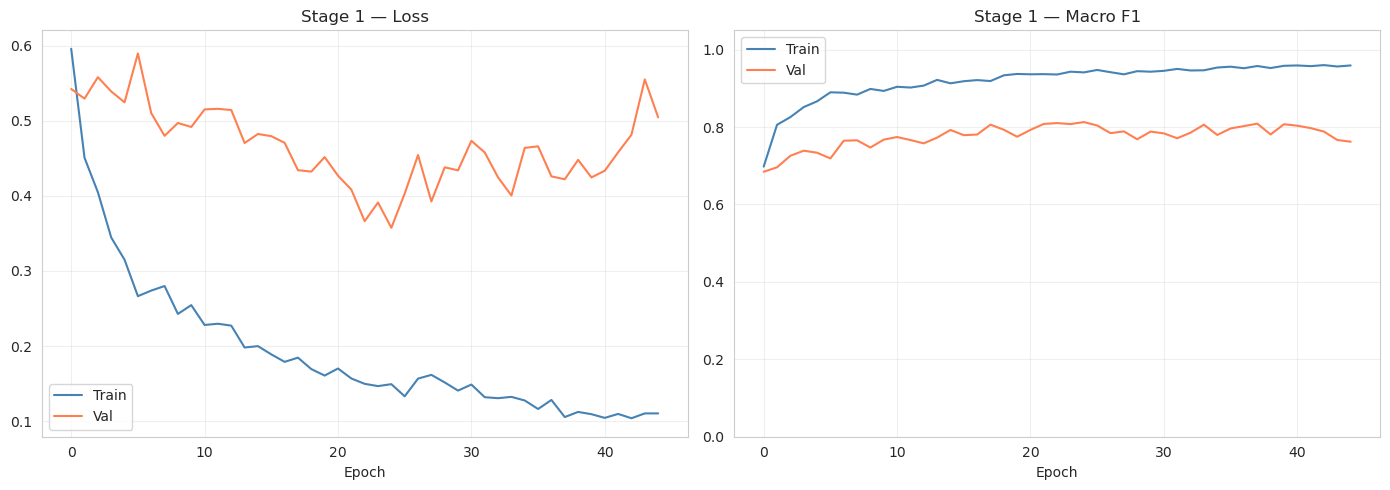

In [12]:
plot_training_curves(hist1, 'Stage 1', 'v8_stage1_curves.png')

### Stage 1 - Test Evaluation

Loaded Stage 1 from epoch 25 (val F1 = 0.8130)

  STAGE 1 — TEST RESULTS
  Accuracy: 0.8261
  Macro F1: 0.7694

              precision    recall  f1-score   support

      normal      0.848     0.922     0.884       412
  suspicious      0.748     0.583     0.655       163

    accuracy                          0.826       575
   macro avg      0.798     0.753     0.769       575
weighted avg      0.820     0.826     0.819       575



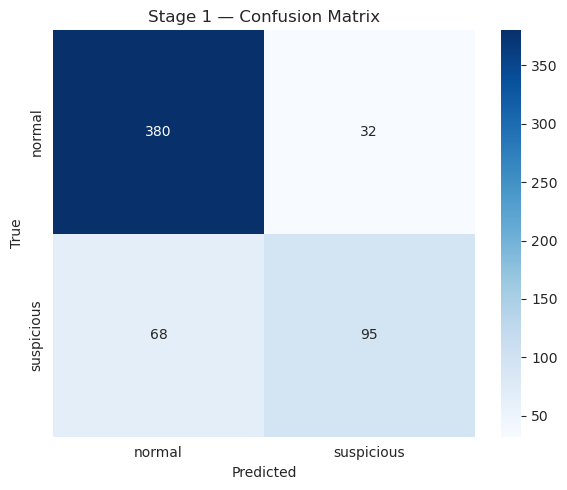

In [13]:
# Evaluate Stage 1 on test set

# Load the best model (saved during training at peak val F1)
ckpt1 = torch.load(S1_MODEL_PATH, map_location=device, weights_only=True)
model1.load_state_dict(ckpt1['state_dict'])
print(f'Loaded Stage 1 from epoch {ckpt1["epoch"]+1} (val F1 = {ckpt1["val_f1"]:.4f})')

model1.eval()
preds1, trues1 = [], []
with torch.no_grad():
    for xb, yb in dl1_te:
        logits = model1(xb.to(device))
        preds1.extend(logits.argmax(1).cpu().numpy())
        trues1.extend(yb.numpy())
preds1 = np.array(preds1)
trues1 = np.array(trues1)

print(f'\n{"="*60}')
print(f'  STAGE 1 — TEST RESULTS')
print(f'{"="*60}')
print(f'  Accuracy: {accuracy_score(trues1, preds1):.4f}')
print(f'  Macro F1: {f1_score(trues1, preds1, average="macro"):.4f}')
print(f'\n{classification_report(trues1, preds1, target_names=le1.classes_, digits=3, zero_division=0)}')

# Confusion matrix
cm1 = confusion_matrix(trues1, preds1)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le1.classes_, yticklabels=le1.classes_, ax=ax)
ax.set_title('Stage 1 — Confusion Matrix')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v8_stage1_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Stage 2 - Suspicious Subtype Classifier

Trained **only on windows that are actually suspicious** (ground-truth labels).
At inference time, Stage 1 acts as a filter only windows predicted "suspicious"
are passed to Stage 2.

This is a **5-class** problem (no normal, no using_phone):
1. `looking_sideways`
2. `leaning_to_neighbor`
3. `talking_to_neighbor`
4. `looking_down`
5. `passing_note`

A separate `StandardScaler` (`sc2`) is fitted on suspicious-only training data,
because the feature distributions differ between normal and suspicious windows.

In [14]:
#  Prepare Stage 2 data (suspicious windows only)

# Filter to suspicious windows only
sus_mask   = all_labels_2 == 'suspicious'
X2_all     = all_features[sus_mask]
y2_labels  = all_labels_7[sus_mask]  # String labels: the 5 suspicious class names

# Encode to integers
le2 = LabelEncoder()
le2.fit(SUSPICIOUS_CLASSES)
y2_all = le2.transform(y2_labels)

# Apply the SAME scenario split to the suspicious subset
# (we need the scenario_id of each suspicious window)
meta_df_sus = pd.DataFrame([m for m, s in zip(all_meta, sus_mask) if s])
sids_sus = meta_df_sus['scenario_id'].values

tr2 = np.isin(sids_sus, list(train_scenarios))
va2 = np.isin(sids_sus, list(val_scenarios))
te2 = np.isin(sids_sus, list(test_scenarios))

# Fit a SEPARATE scaler on suspicious-only training data
sc2 = StandardScaler()
X2_tr = sc2.fit_transform(X2_all[tr2]).astype(np.float32)
X2_va = sc2.transform(X2_all[va2]).astype(np.float32)
X2_te = sc2.transform(X2_all[te2]).astype(np.float32)

y2_tr = y2_all[tr2]
y2_va = y2_all[va2]
y2_te = y2_all[te2]

save_ckpt(sc2, S2_SCALER_PATH)

print(f'\nStage 2 — suspicious windows only')
print(f'  Train: {len(X2_tr)},  Val: {len(X2_va)},  Test: {len(X2_te)}')
print(f'\n  Train distribution:')
for i, name in enumerate(le2.classes_):
    n = int((y2_tr == i).sum())
    print(f'    {name:<25s} {n:4d}')

# Balanced sampler for Stage 2
cc2 = np.bincount(y2_tr, minlength=NUM_SUSPICIOUS).astype(np.float64)
sw2 = (1.0 / np.maximum(cc2, 1))[y2_tr]
sw2 = sw2 / sw2.sum()
sampler2 = WeightedRandomSampler(sw2, len(sw2), replacement=True)

dl2_tr = DataLoader(
    TensorDataset(torch.FloatTensor(X2_tr), torch.LongTensor(y2_tr)),
    batch_size=BS, sampler=sampler2,
)
dl2_va = DataLoader(
    TensorDataset(torch.FloatTensor(X2_va), torch.LongTensor(y2_va)),
    batch_size=BS, shuffle=False,
)
dl2_te = DataLoader(
    TensorDataset(torch.FloatTensor(X2_te), torch.LongTensor(y2_te)),
    batch_size=BS, shuffle=False,
)

  Saved: stage2_scaler_v8.pkl (2.3 KB)

Stage 2 — suspicious windows only
  Train: 732,  Val: 147,  Test: 163

  Train distribution:
    leaning_to_neighbor        203
    looking_down               122
    looking_sideways           169
    passing_note                62
    talking_to_neighbor        176


In [15]:
# Train Stage 2

print('=' * 60)
print('  STAGE 2: Suspicious Subtype Classification')
print('=' * 60)

# NOTE: Output dimension is NUM_SUSPICIOUS = 5 (not 6!)
model2 = Classifier(NUM_FEATURES, H1, H2, NUM_SUSPICIOUS, DROP).to(device)
n_params = sum(p.numel() for p in model2.parameters())
print(f'  Parameters: {n_params:,}')
print(f'  Output classes: {NUM_SUSPICIOUS} — {list(le2.classes_)}\n')

hist2, best_f1_s2 = train_model(model2, dl2_tr, dl2_va, NUM_SUSPICIOUS, S2_MODEL_PATH)

  STAGE 2: Suspicious Subtype Classification
  Parameters: 19,105
  Output classes: 5 — ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'passing_note', 'talking_to_neighbor']

  Ep   1/150  loss=1.5031/1.5602  F1=0.3070/0.3188  lr=1.0e-03  ★ new best
  Ep   2/150  loss=1.2870/1.4634  F1=0.5108/0.4383  lr=1.0e-03  ★ new best
  Ep   3/150  loss=1.0995/1.3860  F1=0.6270/0.4892  lr=1.0e-03  ★ new best
  Ep   4/150  loss=0.9493/1.3021  F1=0.6498/0.5377  lr=1.0e-03  ★ new best
  Ep   5/150  loss=0.7951/1.1964  F1=0.7300/0.5695  lr=1.0e-03  ★ new best
  Ep   6/150  loss=0.6795/1.1070  F1=0.7931/0.5720  lr=1.0e-03  ★ new best
  Ep   7/150  loss=0.5988/1.0430  F1=0.8000/0.5874  lr=1.0e-03  ★ new best
  Ep   9/150  loss=0.4717/1.0490  F1=0.8265/0.5990  lr=1.0e-03  ★ new best
  Ep  10/150  loss=0.3908/1.0379  F1=0.8765/0.6174  lr=1.0e-03  ★ new best
  Ep  11/150  loss=0.3942/0.9857  F1=0.8641/0.6452  lr=1.0e-03  ★ new best
  Ep  19/150  loss=0.2187/1.0371  F1=0.9333/0.6562  lr=1.0e-03

### Stage 2 - Training Curves

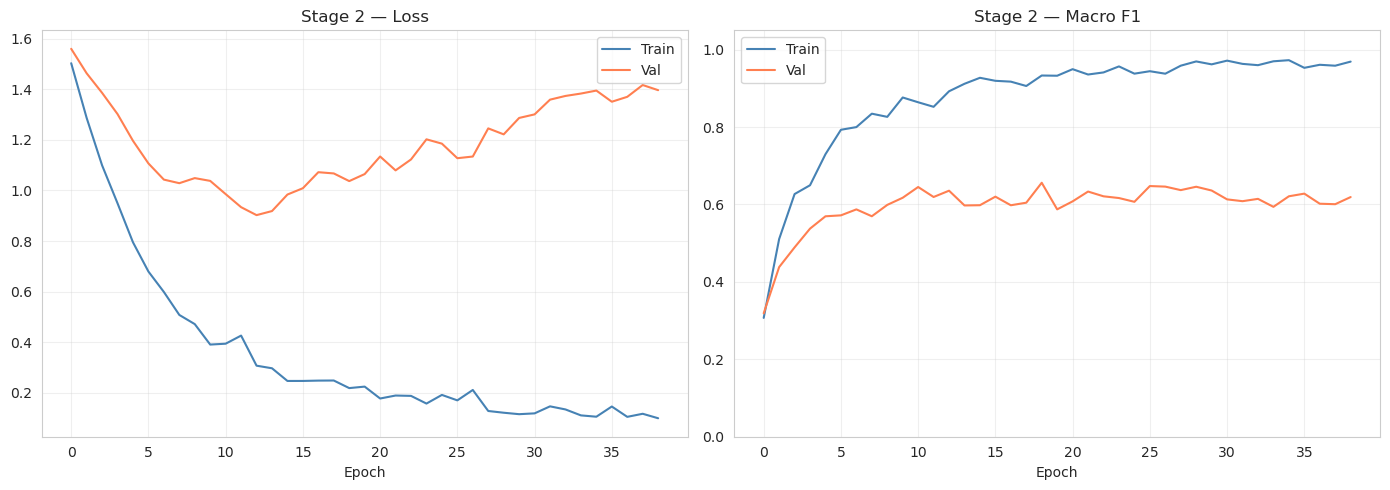

In [16]:
plot_training_curves(hist2, 'Stage 2', 'v8_stage2_curves.png')

### Stage 2 - Test Evaluation

Loaded Stage 2 from epoch 19 (val F1 = 0.6562)

  STAGE 2 — TEST RESULTS (suspicious only)
  Accuracy: 0.5521
  Macro F1: 0.5345

                     precision    recall  f1-score   support

leaning_to_neighbor      0.632     0.286     0.393        42
       looking_down      0.711     0.970     0.821        33
   looking_sideways      0.657     0.523     0.582        44
       passing_note      0.452     0.778     0.571        18
talking_to_neighbor      0.273     0.346     0.305        26

           accuracy                          0.552       163
          macro avg      0.545     0.580     0.535       163
       weighted avg      0.577     0.552     0.536       163



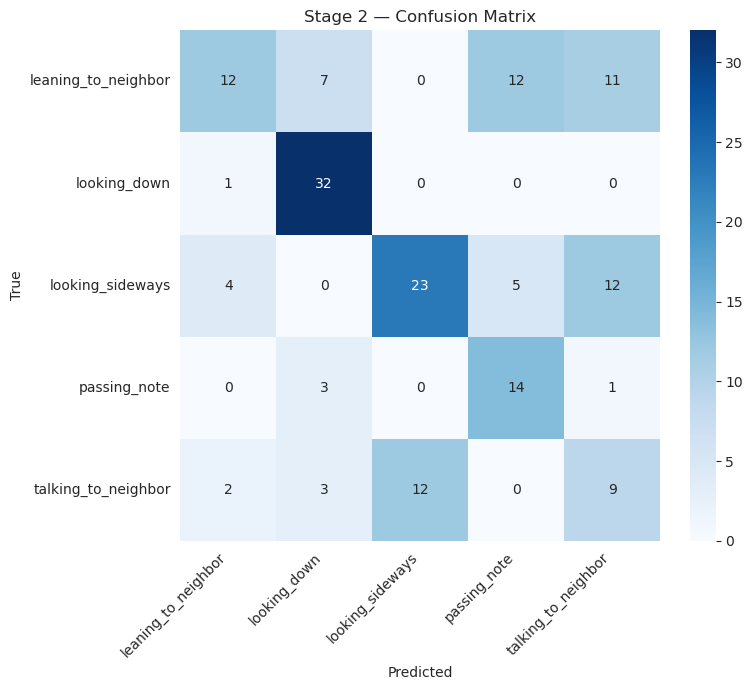

In [17]:
#  Evaluate Stage 2 on test set

ckpt2 = torch.load(S2_MODEL_PATH, map_location=device, weights_only=True)
model2.load_state_dict(ckpt2['state_dict'])
print(f'Loaded Stage 2 from epoch {ckpt2["epoch"]+1} (val F1 = {ckpt2["val_f1"]:.4f})')

model2.eval()
preds2, trues2 = [], []
with torch.no_grad():
    for xb, yb in dl2_te:
        logits = model2(xb.to(device))
        preds2.extend(logits.argmax(1).cpu().numpy())
        trues2.extend(yb.numpy())
preds2 = np.array(preds2)
trues2 = np.array(trues2)

print(f'\n{"="*60}')
print(f'  STAGE 2 — TEST RESULTS (suspicious only)')
print(f'{"="*60}')
print(f'  Accuracy: {accuracy_score(trues2, preds2):.4f}')
print(f'  Macro F1: {f1_score(trues2, preds2, average="macro"):.4f}')
print(f'\n{classification_report(trues2, preds2, target_names=le2.classes_, digits=3, zero_division=0)}')

cm2 = confusion_matrix(trues2, preds2, labels=np.arange(NUM_SUSPICIOUS))
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_, ax=ax)
ax.set_title('Stage 2 — Confusion Matrix')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v8_stage2_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## 9. Combined Two-Stage Pipeline Evaluation

Simulates the full inference pipeline on the test set:

1. **Stage 1** predicts normal/suspicious on ALL test windows
2. Windows predicted "suspicious" are passed through **Stage 2** for subtype classification
3. Windows predicted "normal" by Stage 1 stay as "normal" (Stage 2 is never called)
4. The combined 6-class predictions are evaluated against ground truth

This is the metric that matters for the final system it captures both
Stage 1 filtering errors AND Stage 2 classification errors.

In [18]:
#  Run combined pipeline on test set

# 6-class label encoder
le_6 = LabelEncoder()
le_6.fit(ALL_CLASSES)
y6_te = le_6.transform(all_labels_7[te_m])

# Stage 1: binary prediction on ALL test windows
model1.eval()
s1_preds = []
with torch.no_grad():
    for xb, _ in dl1_te:
        logits = model1(xb.to(device))
        s1_preds.extend(logits.argmax(1).cpu().numpy())
s1_preds = np.array(s1_preds)

sus_idx_1 = le1.transform(['suspicious'])[0]  # integer label for "suspicious"
flagged = np.where(s1_preds == sus_idx_1)[0]
print(f'Stage 1 flagged {len(flagged)} / {len(s1_preds)} test windows as suspicious')

# Stage 2: classify the flagged windows
# Start with everything predicted as normal
combined = np.full(len(s1_preds), le_6.transform(['normal'])[0])

if len(flagged) > 0:
    # Scale the flagged windows using Stage 2's scaler
    X_flagged = sc2.transform(all_features[te_m][flagged]).astype(np.float32)

    model2.eval()
    s2_preds = []
    with torch.no_grad():
        for start in range(0, len(X_flagged), BS):
            xb = torch.FloatTensor(X_flagged[start:start + BS]).to(device)
            logits = model2(xb)
            s2_preds.extend(logits.argmax(1).cpu().numpy())

    # Map Stage 2 predictions back to 6-class indices
    for i, window_idx in enumerate(flagged):
        subtype_name = le2.classes_[s2_preds[i]]
        combined[window_idx] = le_6.transform([subtype_name])[0]

# Evaluate combined predictions

comb_acc = accuracy_score(y6_te, combined)
comb_f1  = f1_score(y6_te, combined, average='macro', zero_division=0)

print(f'\n{"="*60}')
print(f'  COMBINED PIPELINE — TEST RESULTS')
print(f'{"="*60}')
print(f'  Accuracy:  {comb_acc:.4f}')
print(f'  Macro F1:  {comb_f1:.4f}')
print(f'\n{classification_report(y6_te, combined, target_names=le_6.classes_, digits=3, zero_division=0)}')

Stage 1 flagged 127 / 575 test windows as suspicious

  COMBINED PIPELINE — TEST RESULTS
  Accuracy:  0.7565
  Macro F1:  0.4738

                     precision    recall  f1-score   support

leaning_to_neighbor      0.550     0.262     0.355        42
       looking_down      0.516     0.485     0.500        33
   looking_sideways      0.344     0.250     0.289        44
             normal      0.848     0.922     0.884       412
       passing_note      0.526     0.556     0.541        18
talking_to_neighbor      0.280     0.269     0.275        26

           accuracy                          0.757       575
          macro avg      0.511     0.457     0.474       575
       weighted avg      0.733     0.757     0.739       575



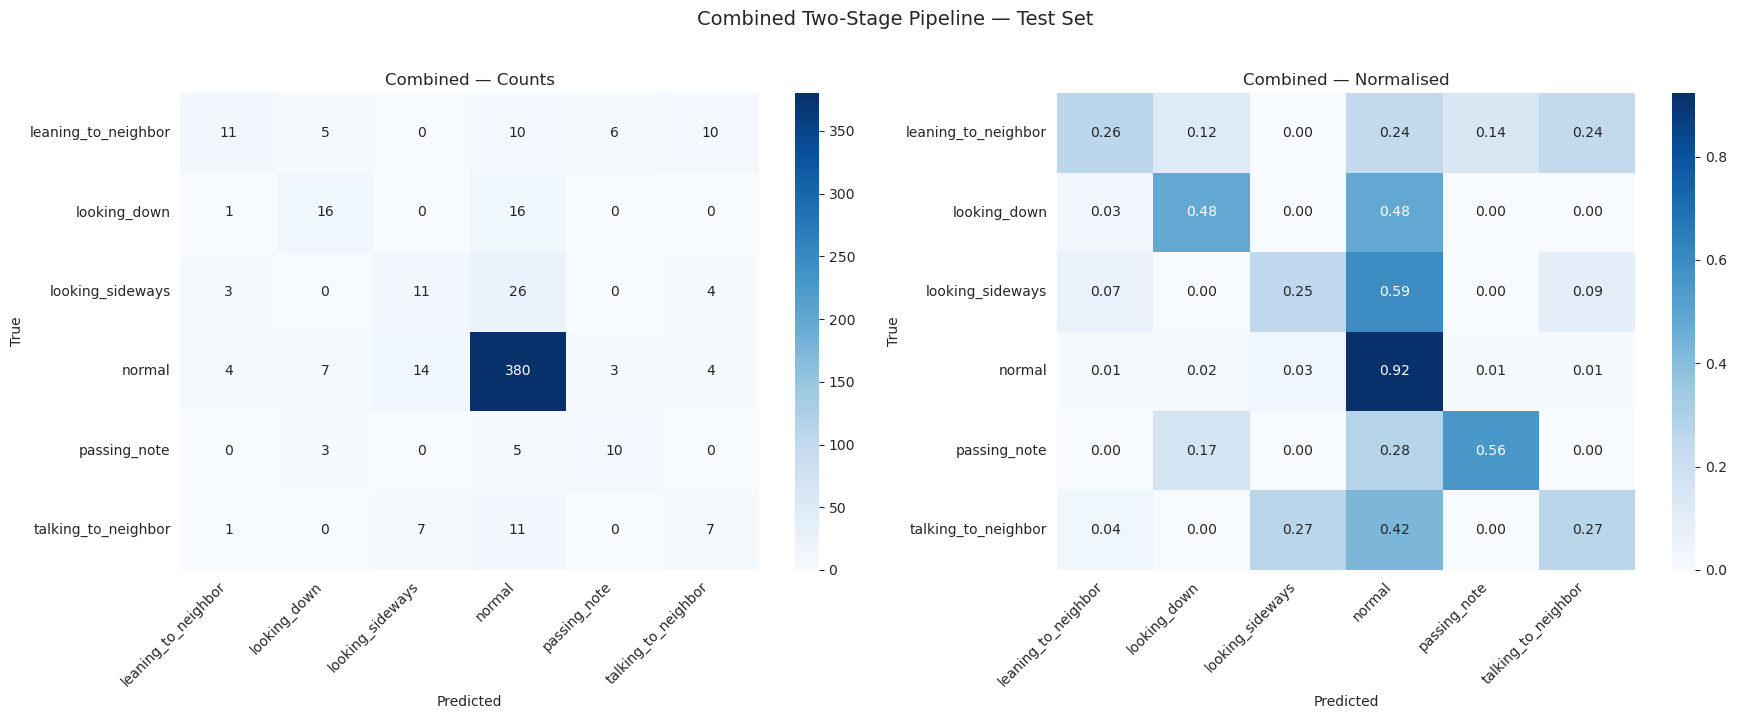

In [19]:
# Combined confusion matrices (counts and normalised)

cm_c   = confusion_matrix(y6_te, combined, labels=np.arange(len(ALL_CLASSES)))
cm_c_n = cm_c.astype(float) / np.maximum(cm_c.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_6.classes_, yticklabels=le_6.classes_, ax=axes[0])
axes[0].set_title('Combined — Counts')

sns.heatmap(cm_c_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_6.classes_, yticklabels=le_6.classes_, ax=axes[1])
axes[1].set_title('Combined — Normalised')

for ax in axes:
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Combined Two-Stage Pipeline — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v8_combined_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

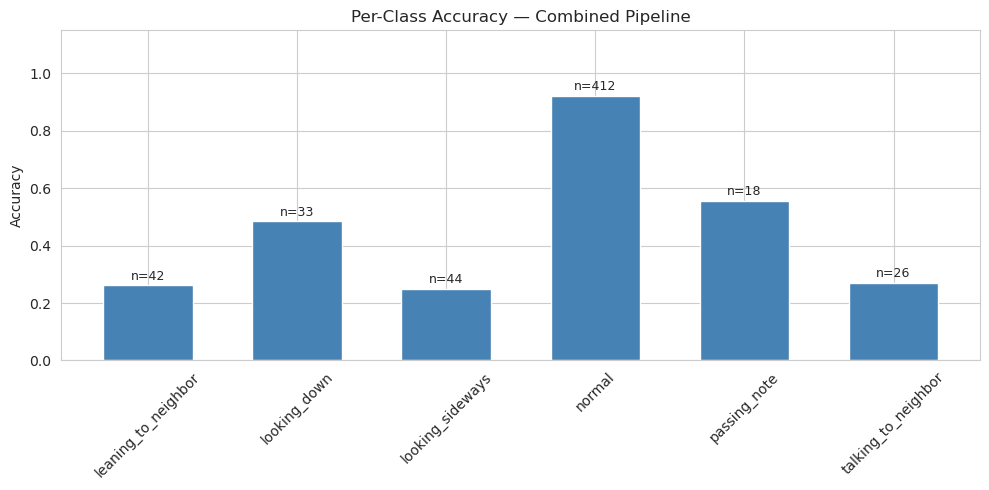

In [20]:
# Per-class accuracy bar chart

fig, ax = plt.subplots(figsize=(10, 5))
cls_data = []
for i, name in enumerate(le_6.classes_):
    mask = y6_te == i
    if mask.sum() > 0:
        acc = float((combined[mask] == y6_te[mask]).mean())
        cls_data.append((name, acc, int(mask.sum())))

names, accs, counts = zip(*cls_data)
bars = ax.bar(names, accs, color='steelblue', edgecolor='white', width=0.6)
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'n={count}',
        ha='center', fontsize=9,
    )
ax.set_title('Per-Class Accuracy — Combined Pipeline')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v8_per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Export Inference Package


In [21]:
#  Export inference package

# Serialise scalers to bytes so they can live inside the .pth file
# (pickle inside pickle, but avoids needing separate .pkl files at inference time)
import io

def scaler_to_bytes(scaler):
    """Serialise a sklearn scaler to bytes for embedding in a .pth file."""
    buf = io.BytesIO()
    pickle.dump(scaler, buf)
    return buf.getvalue()


pkg = {
    # ── Model weights ──
    'stage1_state_dict': model1.state_dict(),
    'stage2_state_dict': model2.state_dict(),

    # ── Scalers (serialised as bytes) ──
    # At inference time: sc = pickle.loads(pkg['stage1_scaler_bytes'])
    'stage1_scaler_bytes': scaler_to_bytes(sc1),
    'stage2_scaler_bytes': scaler_to_bytes(sc2),

    # ── Architecture config (needed to reconstruct Classifier) ──
    'model_config': {
        'input_dim':   NUM_FEATURES,  # 78
        'hidden1':     H1,            # 128
        'hidden2':     H2,            # 64
        'dropout':     DROP,          # 0.3
        'stage1_out':  2,             # normal vs suspicious
        'stage2_out':  NUM_SUSPICIOUS, # 5 suspicious subtypes
    },

    # ── Class mappings ──
    'stage1_classes':     ['normal', 'suspicious'],
    'stage2_classes':     list(le2.classes_),     # 5 suspicious subtypes
    'all_classes':        ALL_CLASSES,            # 6-class list
    'suspicious_classes': SUSPICIOUS_CLASSES,

    # ── Feature config ──
    'feature_names':      FEAT_NAMES,            # 13 base feature names
    'full_feature_names': FULL_FEAT_NAMES,       # 78 aggregated feature names
    'window_size_sec':    3.0,
    'window_stride_sec':  1.0,
    'min_visibility':     0.5,

    # ── Performance metrics ──
    'test_accuracy':      float(comb_acc),
    'test_macro_f1':      float(comb_f1),
    'stage1_best_val_f1': float(best_f1_s1),
    'stage2_best_val_f1': float(best_f1_s2),
}

torch.save(pkg, INFERENCE_PKG_PATH)
pkg_size = os.path.getsize(INFERENCE_PKG_PATH) / 1024
print(f'Inference package saved: {INFERENCE_PKG_PATH} ({pkg_size:.1f} KB)')

# Quick verification: can we load and reconstruct?

verify = torch.load(INFERENCE_PKG_PATH, map_location='cpu', weights_only=False)
sc1_verify = pickle.loads(verify['stage1_scaler_bytes'])
sc2_verify = pickle.loads(verify['stage2_scaler_bytes'])
print(f'  Verification: scalers loaded OK (sc1 mean shape={sc1_verify.mean_.shape}, sc2 mean shape={sc2_verify.mean_.shape})')

Inference package saved: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/inference_package_v8.pth (173.1 KB)
  Verification: scalers loaded OK (sc1 mean shape=(78,), sc2 mean shape=(78,))
